# Code to AI — Week 6, Day 1: Finding & Fixing Missing Data
**Pandas II — Data Cleaning**

---

Welcome back! Last week you learned how to load, filter and explore a dataset. But real data is almost never clean. Values go missing, people type things differently, and rows get duplicated. This week we learn to fix that.

Today we tackle the most common problem of all: **missing values**.

**By the end of this notebook you will be able to:**
- Measure how much data is missing, and where
- Decide between dropping and filling missing values
- Use `.dropna()` to remove missing data safely
- Use `.fillna()` to replace missing data sensibly
- Choose between mean, median and mode when filling

## 0. Setup

We only need pandas and seaborn today. Seaborn gives us the Titanic dataset you
already met in Week 5 — but this time we are going to actually **clean** it.

In [26]:
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 30)
print("pandas version:", pd.__version__)
print("Ready to go!")

pandas version: 3.0.3
Ready to go!


---
## 1. Why messy data matters

Imagine you are asked: *"What was the average age of passengers on the Titanic?"*

You write one line of code, get a number, and report it. But what if 20% of the ages
were never recorded? Your average is now based on incomplete data — and nobody told you.

This is the whole point of data cleaning: **you cannot trust an answer until you know
what was missing from the question.**

Let's load the data and look.

In [27]:
df = sns.load_dataset('titanic')

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## 2. Inspecting data quality

Three tools, used in this order, every single time you open a new dataset.

### 2.1 `.info()` — the overview

This shows every column, how many **non-null** (non-missing) values it has, and its type.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Look carefully at the `Non-Null Count` column above. The dataset has 891 rows.
Any column showing fewer than 891 non-null values has missing data.

That works, but counting by eye is slow. Let's ask pandas directly.

### 2.2 `.isnull().sum()` — the exact count

`.isnull()` turns the whole table into `True` / `False`, where `True` means "this value is missing".
Then `.sum()` counts the `True` values in each column.

In [30]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [31]:
missing_count = df.isnull().sum()
print(missing_count)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Now sort it so the worst columns come first — much easier to read.

In [32]:
missing_count = df.isnull().sum().sort_values(ascending=False)
print(missing_count)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64


### 2.3 `.isnull().mean() * 100` — the percentage

A count of 177 means nothing until you know the total. 177 out of 891 is a lot.
177 out of 10 million would be nothing.

`.mean()` on `True`/`False` values gives you the **proportion** that are `True`.
Multiply by 100 and you have a percentage.

In [33]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print(missing_percent.round(1))

deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
sex             0.0
pclass          0.0
survived        0.0
fare            0.0
parch           0.0
sibsp           0.0
class           0.0
adult_male      0.0
who             0.0
alive           0.0
alone           0.0
dtype: float64


### 2.4 A proper missing-value report

Let's put the count and the percentage side by side in one small table.
This is a snippet you will reuse in every project from now on.

In [34]:
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})

# Keep only the columns that actually have missing values
report = report[report['missing_count'] > 0]
report = report.sort_values('missing_percent', ascending=False)

report

,missing_count,missing_percent
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


Read that table out loud:

- `deck` is missing about 77% of its values — three quarters of the column is empty.
- `age` is missing about 20% — significant, but most of the column is fine.
- `embarked` and `embark_town` are each missing just 2 values out of 891 — almost nothing.

Three very different problems. They need three different solutions.

---
## 3. The three options

Whenever you find missing data you have exactly three choices:

| Option | What it means | When it makes sense |
|--------|---------------|---------------------|
| **Drop the rows** | Delete the rows that have missing values | Very few rows affected |
| **Drop the column** | Delete the whole column | Most of the column is empty |
| **Fill the values** | Replace missing with a sensible substitute | The column matters and enough data exists |

There is no universal right answer. The right answer depends on **how much** is missing
and **how important** that column is to your question.

A rough rule of thumb to start with:

- Missing under ~5% → dropping those rows is usually safe
- Missing 5–40% → filling is usually better than losing all those rows
- Missing over ~60% → the column often has too little information to be useful

Treat these as starting points for thinking, not laws.

---
## 4. The golden rule: always work on a copy

Before we change anything, one habit that will save you a lot of pain.

**Never modify your original DataFrame.** Make a copy, clean the copy, and keep the
original untouched so you can always compare or start over.

In [35]:
# The original stays safe. We clean 'clean_df'.
clean_df = df.copy()


print("Original rows:", len(df))
print("Copy rows:    ", len(clean_df))

Original rows: 891
Copy rows:     891


Why `.copy()` and not just `clean_df = df`? Because `clean_df = df` does **not** make a
new table — it just gives the same table a second name. Change one, and you change both.
`.copy()` makes a genuine independent copy.

---
## 5. Dropping missing values with `.dropna()`

### 5.1 The default: drop any row with any missing value

Be careful with this one. It is much more aggressive than beginners expect.

In [38]:
df.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
404,0,3,female,20.0,0,0,8.6625,S,Third,woman,False,NaN,Southampton,no,True
29,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
392,0,3,male,28.0,2,0,7.9250,S,Third,man,True,NaN,Southampton,no,False
678,0,3,female,43.0,1,6,46.9000,S,Third,woman,False,NaN,Southampton,no,False
694,0,1,male,60.0,0,0,26.5500,S,First,man,True,NaN,Southampton,no,True
838,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
189,0,3,male,36.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
610,0,3,female,39.0,1,5,31.2750,S,Third,woman,False,NaN,Southampton,no,False
642,0,3,female,2.0,3,2,27.9000,S,Third,child,False,NaN,Southampton,no,False


In [39]:
dropped_all = df.dropna()

print("Before:", len(df), "rows")
print("After: ", len(dropped_all), "rows")
print("Lost:  ", len(df) - len(dropped_all), "rows")

Before: 891 rows
After:  182 rows
Lost:   709 rows


In [40]:
dropped_all

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


Look at that result. We started with 891 rows and were left with a small fraction of them.

Why? Because `deck` is missing in 688 rows, so `.dropna()` deleted every one of those rows —
even though the rest of each row was perfectly good data. **One bad column destroyed most
of the dataset.**

This is the single most common data-cleaning mistake. Never call `.dropna()` with no
arguments unless you have checked what it will cost you.

### 5.2 `subset=` — only care about specific columns

Much better: tell pandas *which* columns you actually need to be complete.

`embarked` is only missing 2 values, so dropping those 2 rows is cheap and sensible.

In [41]:
dropped_subset = df.dropna(subset=['embarked'])

print("Before:", len(df), "rows")
print("After: ", len(dropped_subset), "rows")
print("Lost:  ", len(df) - len(dropped_subset), "rows")

Before: 891 rows
After:  889 rows
Lost:   2 rows


Two rows lost out of 891. That is a good trade.

You can list several columns too — a row is dropped if **any** of the listed columns is missing.

In [42]:
dropped_two = df.dropna(subset=['embarked', 'embark_town'])
print("Rows remaining:", len(dropped_two))

Rows remaining: 889


### 5.3 `how='any'` vs `how='all'`

- `how='any'` (the default) — drop the row if **any** value in it is missing
- `how='all'` — drop the row only if **every** value in it is missing

`how='all'` is for removing completely blank rows, which happens a lot in exported
spreadsheets. On Titanic there are none, so nothing is lost.

In [43]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [44]:
dropped_any = df.dropna(how='any')
dropped_all_blank = df.dropna(how='all')

print("how='any' leaves:", len(dropped_any), "rows")
print("how='all' leaves:", len(dropped_all_blank), "rows")

how='any' leaves: 182 rows
how='all' leaves: 891 rows


### 5.4 `axis=1` — drop columns instead of rows

So far we have been deleting rows. Setting `axis=1` deletes **columns** that contain
missing values instead.

Remember: `axis=0` means rows, `axis=1` means columns. This is the same everywhere in pandas.

In [45]:
dropped_cols = df.dropna(axis=1)

print("Original columns:", len(df.columns))
print("Remaining columns:", len(dropped_cols.columns))
print()


Original columns: 15
Remaining columns: 11



In [48]:
dropped_cols.shape

(891, 11)

In [49]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [50]:
dropped_cols.columns

Index(['survived', 'pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'alive', 'alone'],
      dtype='str')

In [ ]:
for c in df.columns:
    if c not in dropped_cols.columns:
        c == c

In [ ]:
[c for c in df.columns if c not in dropped_cols.columns]

In [51]:
print("Columns removed:", [c for c in df.columns if c not in dropped_cols.columns])

Columns removed: ['age', 'embarked', 'deck', 'embark_town']


That removed every column with even one missing value — including `age`, which we probably
want to keep. Usually it is better to drop a bad column **by name**, deliberately:

In [52]:
# 'deck' is ~77% empty, so we drop it on purpose
clean_df = clean_df.drop(columns=['deck'])
# clean_df = clean_df.dropna(subset=['deck'], axis=1)

print("Columns now:", len(clean_df.columns))
print(list(clean_df.columns))

Columns now: 14
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [53]:
len(df.columns)

15

In [54]:
clean_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


---
## 6. Filling missing values with `.fillna()`

Dropping loses data. Often we would rather keep the row and put a sensible value in the gap.

### 6.1 Filling with a constant

For text columns, a label like `"Unknown"` is honest and clear — it tells anyone reading
the data that the value was never recorded, rather than hiding the gap.

In [ ]:
print("Missing before:", clean_df['embark_town'].isnull().sum())

clean_df['embark_town'] = clean_df['embark_town'].fillna('Unknown')

print("Missing after: ", clean_df['embark_town'].isnull().sum())
print()
print(clean_df['embark_town'].value_counts())

Missing before: 2
Missing after:  0

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Unknown          2
Name: count, dtype: int64


In [58]:
df[df['embark_town'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True


In [57]:
clean_df[clean_df['embark_town'] == 'Unknown']

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,Unknown,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,Unknown,yes,True


In [59]:
clean_df['embark_town'].isnull().sum()

np.int64(0)

### 6.2 Filling numbers with the mean

For numeric columns, a common approach is to fill gaps with the column's average.

Let's look at `age` first.

In [60]:
print("Missing ages:", clean_df['age'].isnull().sum())
print()
print(clean_df['age'].describe().round(2))

Missing ages: 177

count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: age, dtype: float64


In [63]:
clean_df[clean_df['age' == 38.00]]

KeyError: False

In [61]:
age_mean = clean_df['age'].mean()
age_median = clean_df['age'].median()

print("Mean age:  ", round(age_mean, 2))
print("Median age:", round(age_median, 2))

Mean age:   29.7
Median age: 28.0


### 6.3 Mean vs median — which one?

The **mean** is the arithmetic average: add everything up, divide by the count.
The **median** is the middle value when you line all the values up in order.

They differ when the data is lopsided. Picture five salaries:

`20k, 22k, 25k, 27k, 500k`

- Mean = 118.8k — a number nobody in the list actually earns
- Median = 25k — a fair description of a typical person

One extreme value dragged the mean far away from reality. The median barely moved.

**The rule:** if a column has extreme values (outliers), prefer the **median**.
If the values are fairly evenly spread, the **mean** is fine.

Let's see the shape of `age` for ourselves.

<Axes: title={'center': 'Distribution of Age'}, ylabel='Frequency'>

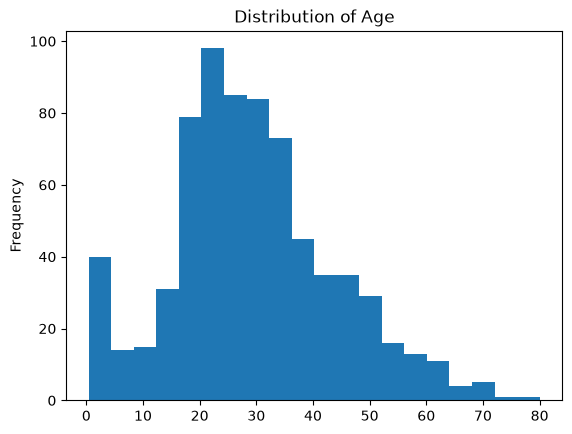

In [ ]:
# A quick visual check of how age is spread out # histrogram
clean_df['age'].plot(kind='hist', bins=20, title='Distribution of Age')

Age here is reasonably balanced with a slight lean toward younger passengers, and the mean
and median are close (about 29.7 vs 28.0). Either would work.

We will use the **median** — it is the safer default whenever you are not sure.

In [65]:
print("Missing before:", clean_df['age'].isnull().sum())

clean_df['age'] = clean_df['age'].fillna(clean_df['age'].median())

print("Missing after: ", clean_df['age'].isnull().sum())

Missing before: 177
Missing after:  0


In [66]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


### 6.4 Filling categories with the mode

The **mode** is simply the most common value. It is what you use for text or category
columns, because "average" makes no sense for words.

`.mode()` returns a small Series (there can be ties), so we take the first entry with `[0]`.

In [67]:
clean_df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [73]:
clean_df['embarked'].mode()[0]

'S'

In [69]:
clean_df[clean_df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,Unknown,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,Unknown,yes,True


In [74]:
print(clean_df['embarked'].value_counts())
print()

embarked_mode = clean_df['embarked'].mode()[0]
print("Most common value:", embarked_mode)

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Most common value: S


In [75]:
print("Missing before:", clean_df['embarked'].isnull().sum())

clean_df['embarked'] = clean_df['embarked'].fillna(embarked_mode)

print("Missing after: ", clean_df['embarked'].isnull().sum())

Missing before: 2
Missing after:  0


In [76]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


### 6.5 Quick summary of the three fills

| Column type | Fill with | Code |
|-------------|-----------|------|
| Text / label | A constant like `"Unknown"` | `.fillna('Unknown')` |
| Numbers, evenly spread | Mean | `.fillna(df['col'].mean())` |
| Numbers with outliers | Median | `.fillna(df['col'].median())` |
| Category | Mode (most common) | `.fillna(df['col'].mode()[0])` |

**One honest warning:** filling is a guess. You are inventing data that was never collected.
It is often the right call, but you must always say what you did — which is why we write it
down in markdown as we go.

---
## 7. Before and after

The final step of any cleaning session: prove that it worked.

In [77]:
before = pd.DataFrame({
    'before_missing': df.isnull().sum()
})
after = pd.DataFrame({
    'after_missing': clean_df.isnull().sum()
})

comparison = before.join(after)
comparison

,before_missing,after_missing
survived,0,0.0
pclass,0,0.0
sex,0,0.0
age,177,0.0
sibsp,0,0.0
parch,0,0.0
fare,0,0.0
embarked,2,0.0
class,0,0.0
who,0,0.0


In [80]:
clean_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')

In [78]:
before

,before_missing
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [79]:
after

,after_missing
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [83]:
df.isnull().sum().sum()

np.int64(869)

In [85]:
clean_df.isnull().sum().sum()

np.int64(0)

In [81]:
print("Total missing values BEFORE:", df.isnull().sum().sum())
print("Total missing values AFTER: ", clean_df.isnull().sum().sum())
print()
print("Rows kept:", len(clean_df), "out of", len(df))
print("Columns:  ", len(clean_df.columns), "(we removed 'deck')")

Total missing values BEFORE: 869
Total missing values AFTER:  0

Rows kept: 891 out of 891
Columns:   14 (we removed 'deck')


Zero missing values, and we kept every single row. Compare that to the naive `.dropna()`
from section 5.1, which threw away most of the dataset.

That difference — between thinking about each column and blindly deleting — is what data
cleaning actually is.

---
## 8. What we covered today

- `.info()`, `.isnull().sum()` and `.isnull().mean() * 100` to find missing data
- Building a reusable missing-value report
- The three options: drop rows, drop the column, or fill
- `.dropna()` with `subset=`, `how=` and `axis=`
- Why bare `.dropna()` is dangerous
- `.fillna()` with a constant, the mean, the median, and the mode
- Choosing mean vs median based on outliers
- Always working on a `.copy()`

**Next up:** the practice notebook, where you do all of this yourself on a new dataset.

Great work today. See you in the lab! 🚀